### Prev. notebooks para google collab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00
✅ Dependencias instaladas
✅ Importaciones completadas
✅ Configuración completada
Lagos: ['Lago de Atitlán', 'Lago de Amatitlán']
Total de escenas: 22

GENERANDO DATOS DE MUESTRA PARA ANÁLISIS
⚠️ Estos son datos sintéticos realistas, NO datos reales de satélite
   Simulan el comportamiento esperado de los lagos de Guatemala

✅ Datos generados: 29,462 observaciones (píxeles)

CUADERNO 1: OBTENCIÓN Y VISUALIZACIÓN DE DATOS

📊 Resumen por lago:

Lago de Atitlán:
  Píxeles: 15,000
  Fechas: 15
  Chl media: 1.74 µg/L
  Chl mediana: 1.67 µg/L
  Chl max: 10.16 µg/L

Lago de Amatitlán:
  Píxeles: 14,462
  Fechas: 15
  Chl media: 8.30 µg/L
  Chl mediana: 7.97 µg/L
  Chl max: 35.93 µg/L

📊 Resumen por fecha (primeras 5):
     lago      fecha  chl_media  chl_mediana  chl_max  chl_p90  ndvi_media  ndwi_media   pct_alto
Amatitlan 2025-01-31       4.55         3.99    13.63     6.15        -0.1        0.50   4.100000
Amatitl

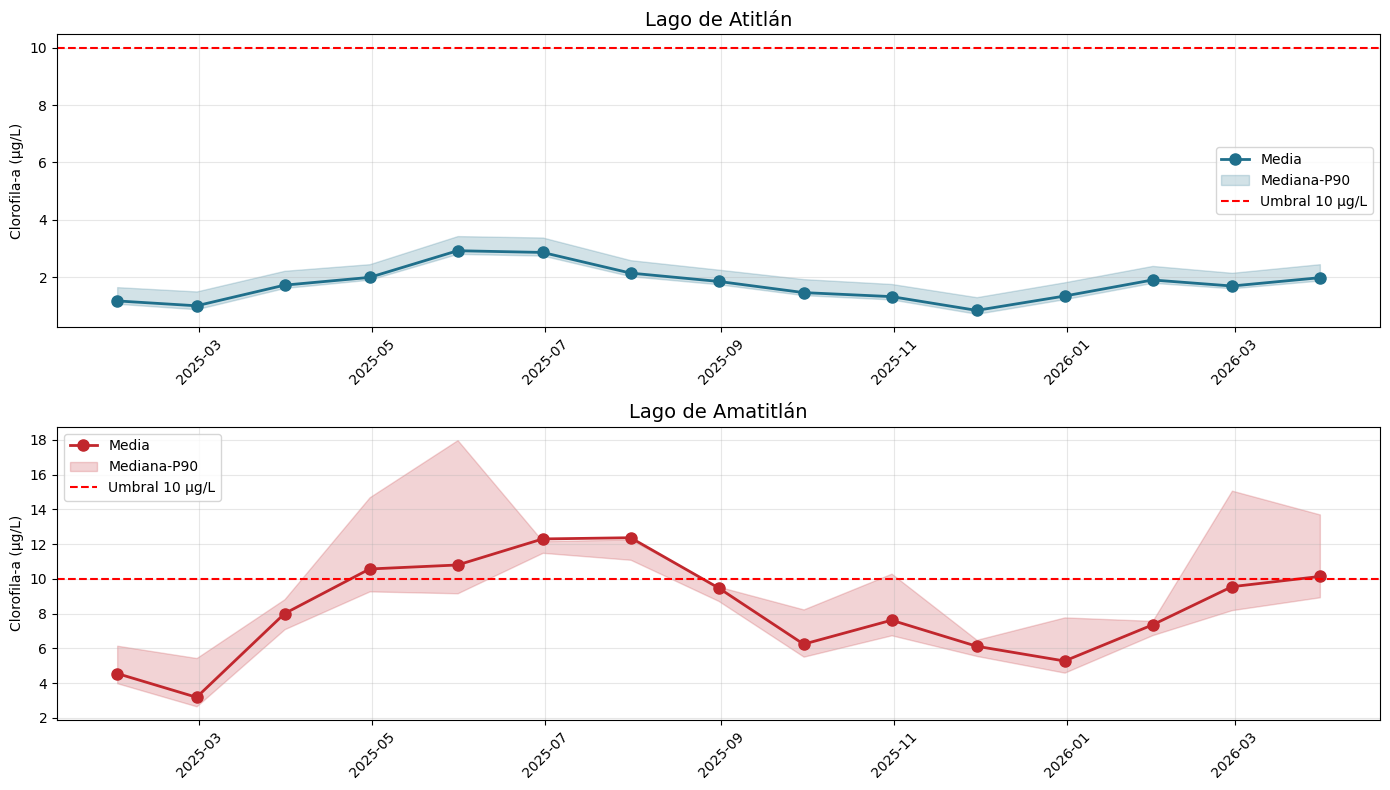


CUADERNO 2: ANÁLISIS TEMPORAL


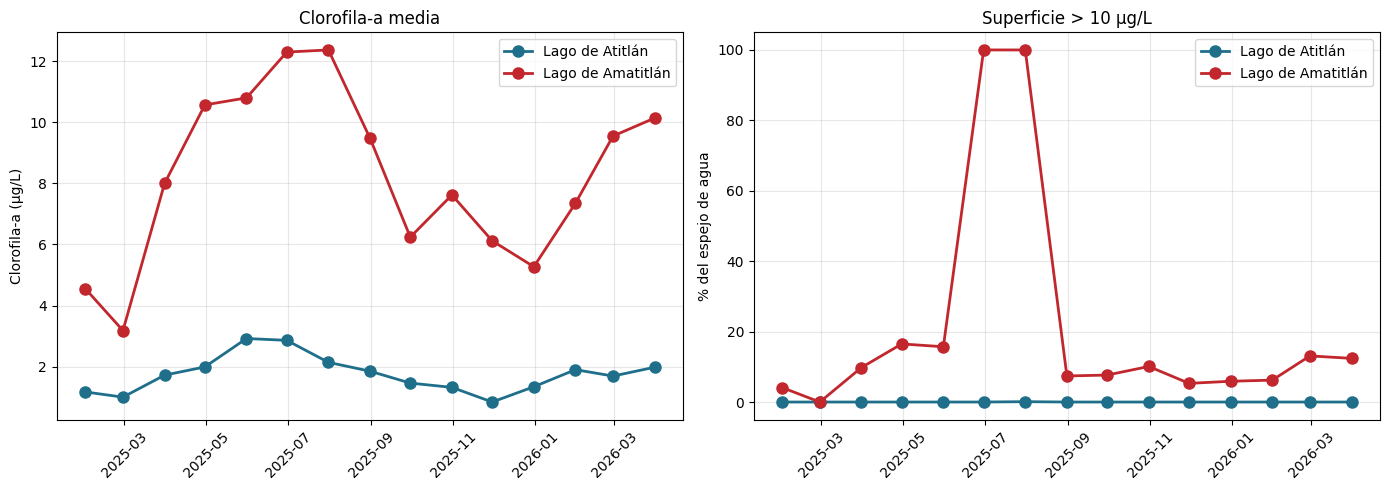


📊 Fechas críticas por lago:

Lago de Atitlán:
  Promedio: 1.75 µg/L
  Umbral anomalía: 2.35 µg/L
  Fechas críticas: 2
    2025-05-31: 2.92 µg/L
    2025-06-30: 2.86 µg/L

Lago de Amatitlán:
  Promedio: 8.24 µg/L
  Umbral anomalía: 11.04 µg/L
  Fechas críticas: 7
    2025-04-30: 10.57 µg/L
    2025-05-31: 10.80 µg/L
    2025-06-30: 12.30 µg/L
    2025-07-31: 12.37 µg/L
    2025-10-31: 7.62 µg/L
    2026-02-28: 9.55 µg/L
    2026-03-31: 10.14 µg/L

CUADERNO 3: ANÁLISIS ESPACIAL


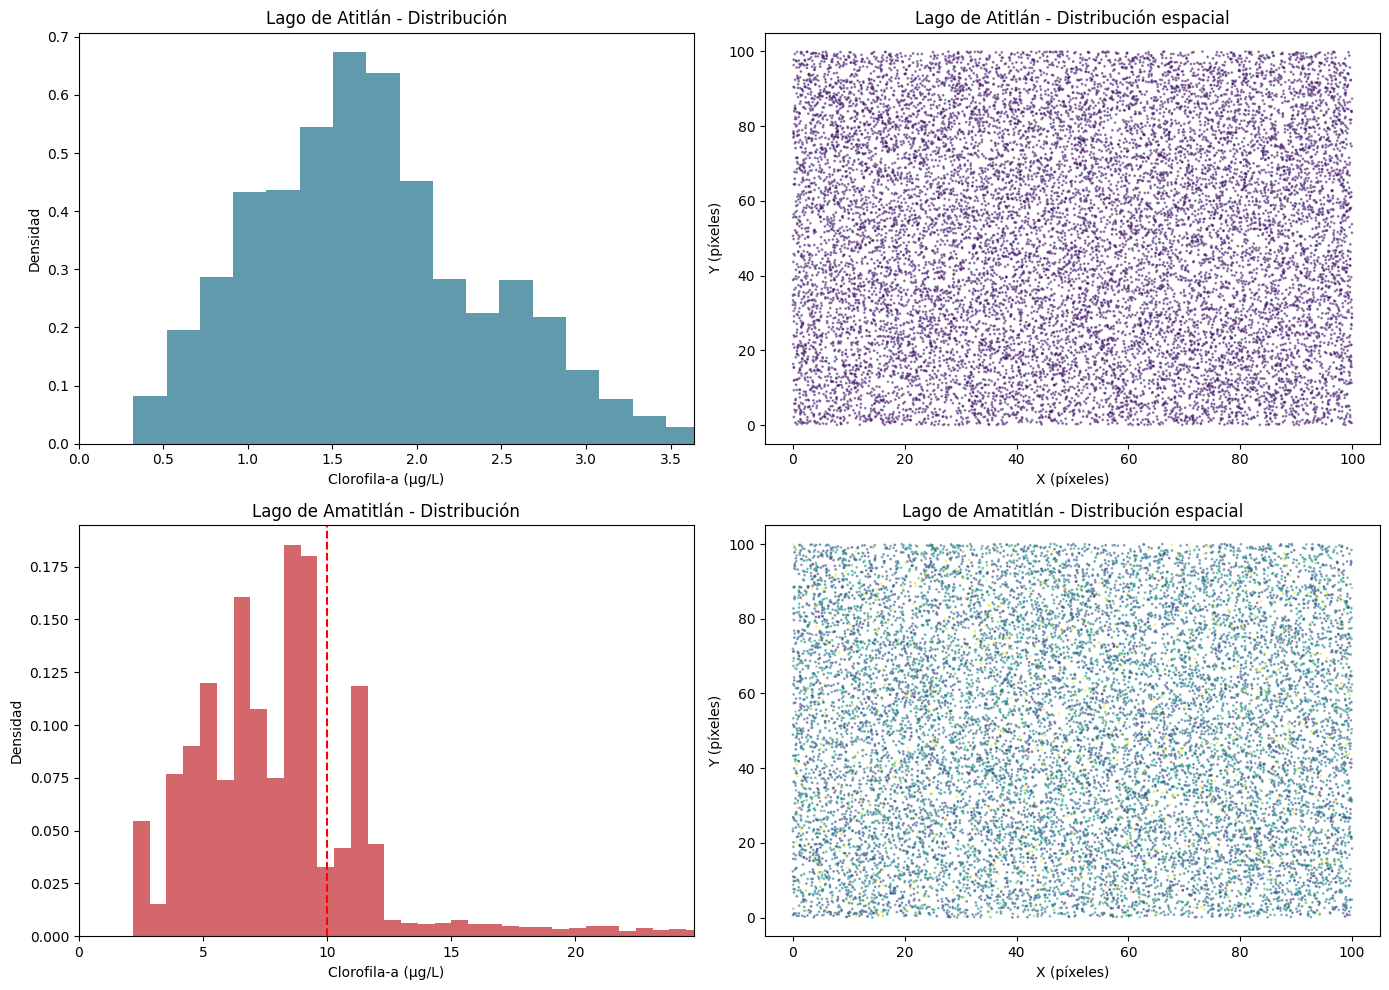


CUADERNO 4: ANÁLISIS DE EXTENSIÓN Y PERSISTENCIA


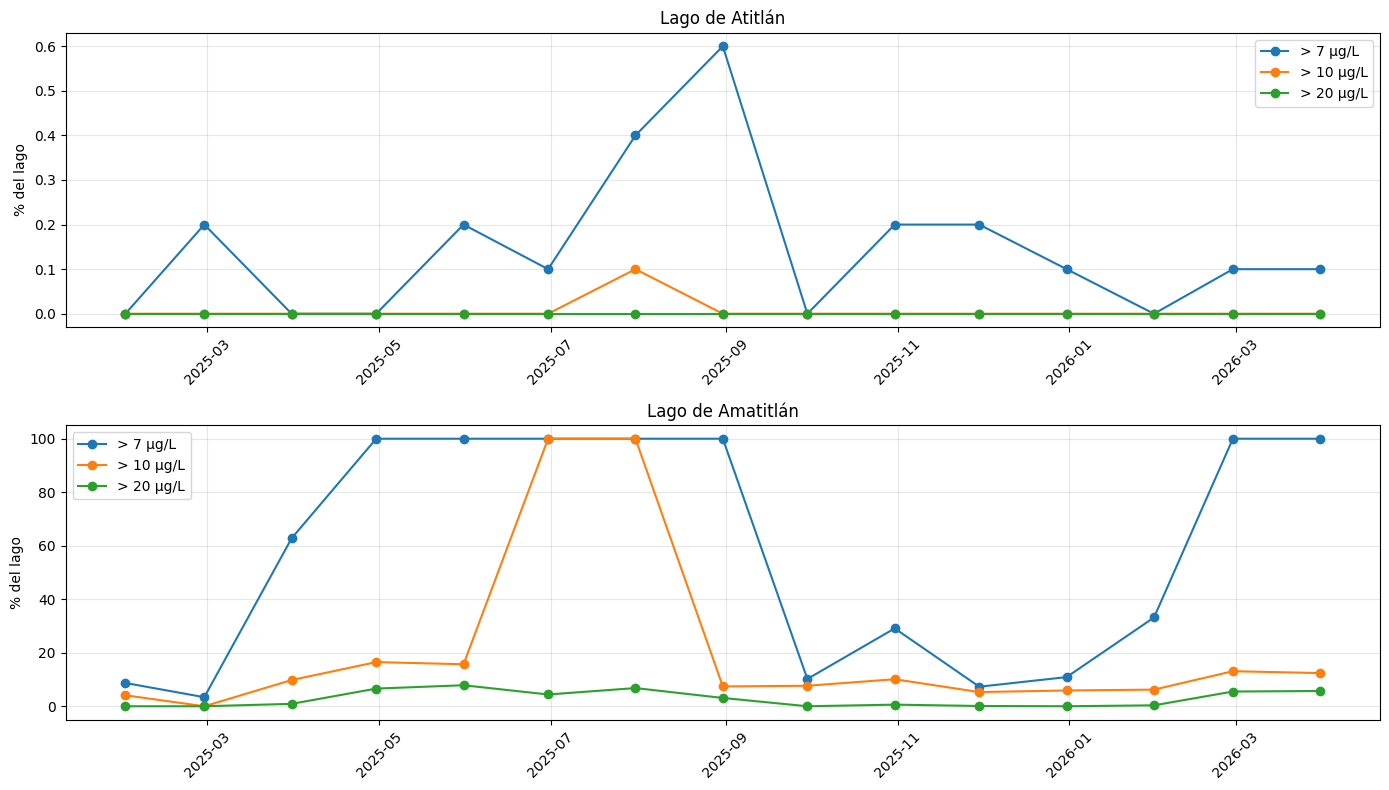


📊 Perfil de persistencia:

Lago de Atitlán:
  Píxeles analizados: 7,780
  Persistencia media: 0.0%
  Persistencia máxima: 33.3%
  Superficie > 25% fechas: 0.0%
  Superficie > 50% fechas: 0.0%

Lago de Amatitlán:
  Píxeles analizados: 7,730
  Persistencia media: 21.6%
  Persistencia máxima: 100.0%
  Superficie > 25% fechas: 33.8%
  Superficie > 50% fechas: 25.6%

CUADERNO 5: CORRELACIONES Y COMPARACIONES

📊 Correlaciones (Spearman) con clorofila:


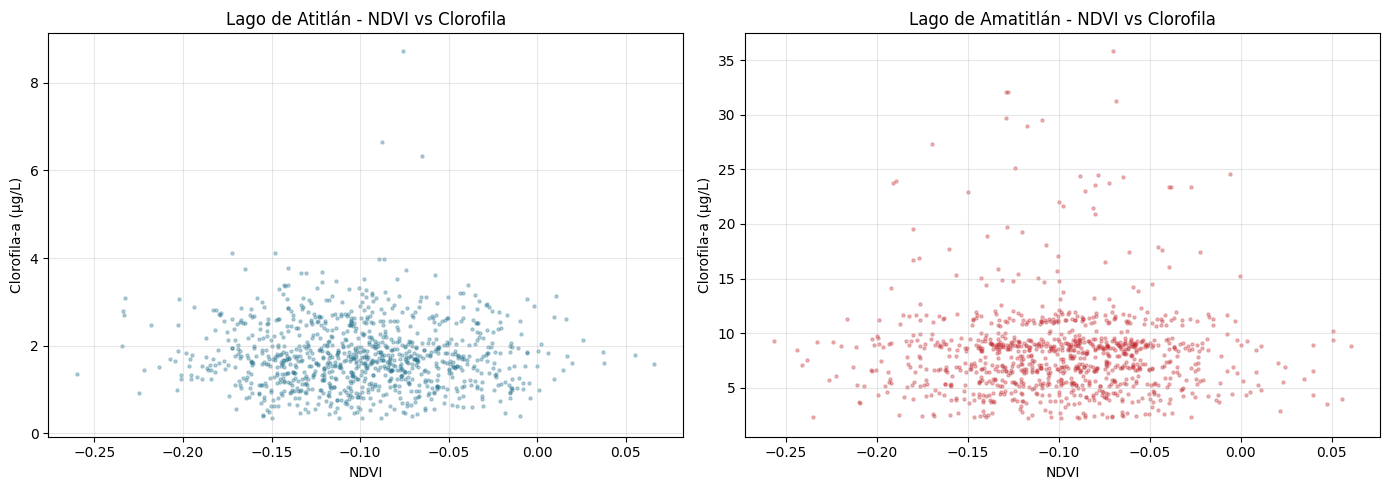


📊 Comparación entre lagos:
          Lago de Amatitlán  Lago de Atitlán
chl_mean               8.24             1.75
chl_min                3.18             0.84
chl_max               12.37             2.92
pct_mean              20.95             0.01
pct_max              100.00             0.10


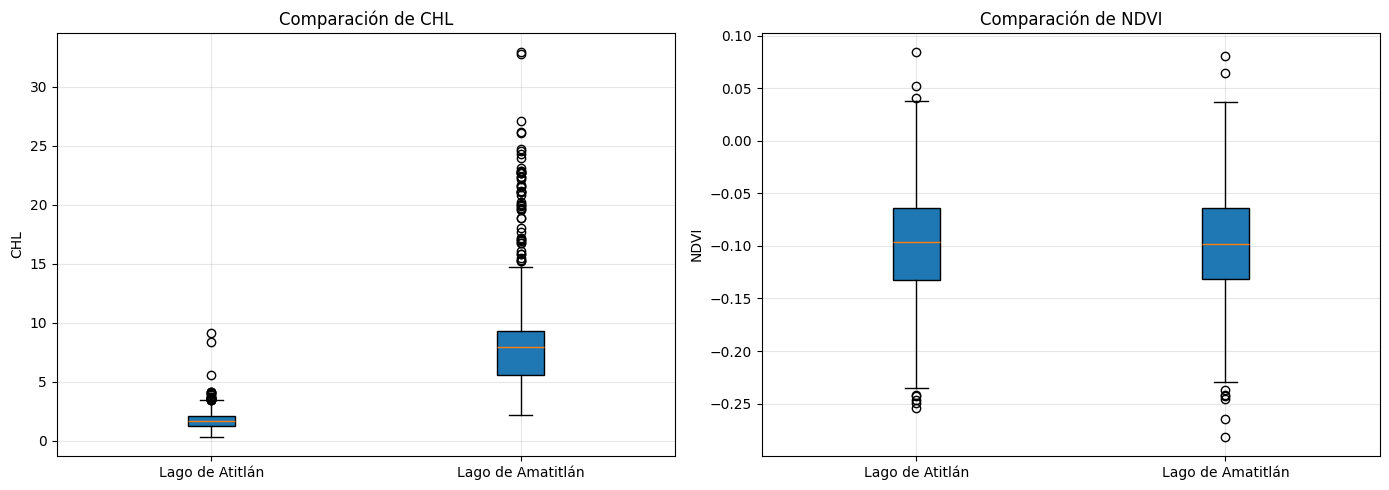


CUADERNO 6: PREPARACIÓN DE DATOS PARA ML
Dataset ML: 29,462 observaciones
Columnas: ['lago', 'fecha', 'chl', 'ndvi', 'ndwi', 'ndci', 'fai', 'B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'x', 'y', 'ciano_presente']

📊 Distribución de la variable objetivo:
ciano_presente
0    26356
1     3106
Name: count, dtype: int64

Proporción clase 1: 10.54%


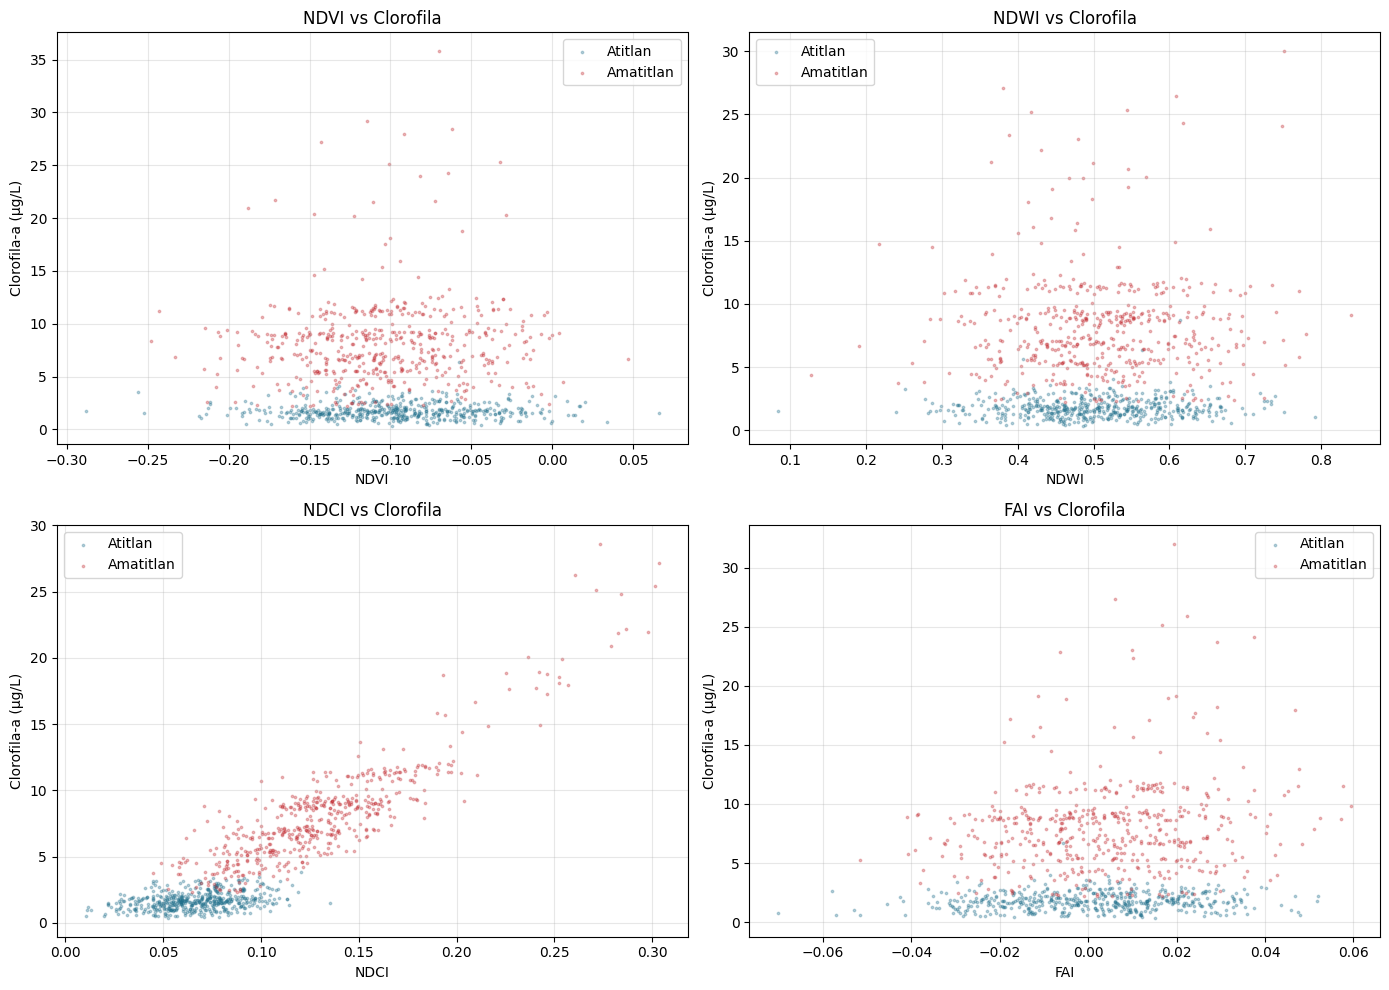


📊 Matriz de correlación:


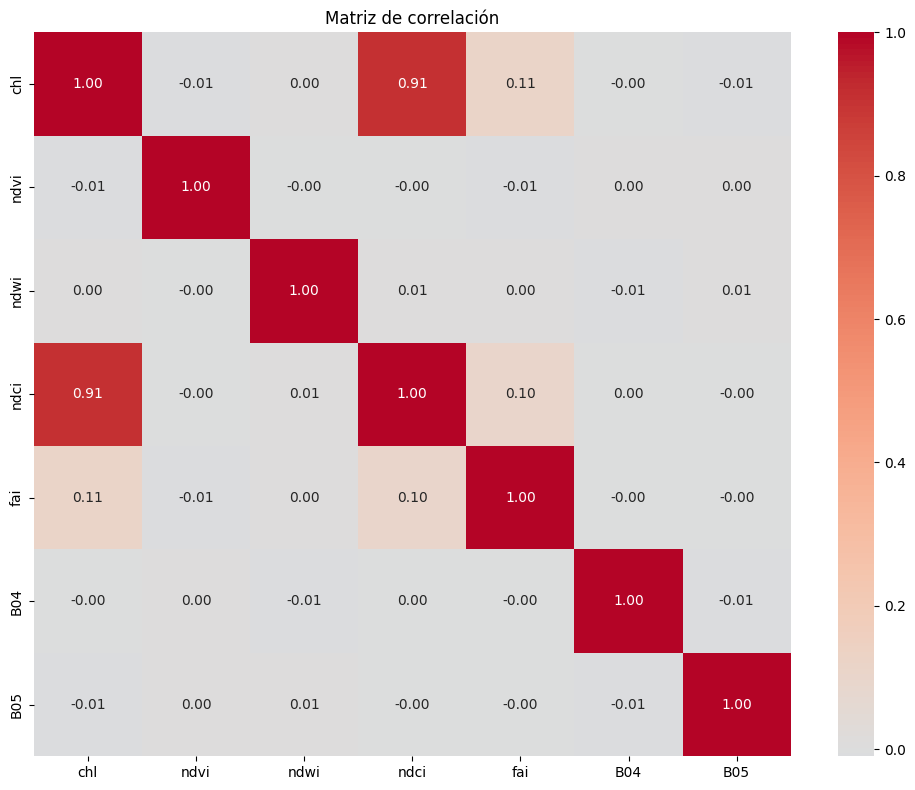


CUADERNO 7: CONSTRUCCIÓN DE VARIABLE RESPUESTA BINARIA

📊 Análisis de desbalance:

Global:
  Clase 0: 26,356 (89.5%)
  Clase 1: 3,106 (10.5%)
  Ratio (0/1): 8.49:1

Lago de Atitlán:
  Clase 1: 0.0%
  Ratio (0/1): 14999.00:1

Lago de Amatitlán:
  Clase 1: 21.5%
  Ratio (0/1): 3.66:1

VARIABLES QUE NO PUEDEN USARSE COMO PREDICTORAS

1. VARIABLES DERIVADAS DE LA VARIABLE RESPUESTA:
   - 'chl': Es la variable respuesta original
   - 'ndci': Fórmula directa de la clorofila
   - 'ciano_presente': Es la variable objetivo

2. VARIABLES RECOMENDADAS COMO PREDICTORAS:
   - Espectrales: B02, B03, B04, B05, B08
   - Índices: ndvi, ndwi, fai
   - Total: 8 variables

3. JUSTIFICACIÓN DEL UMBRAL:
   - Valor seleccionado: 10 µg/L
   - Basado en: OMS (2003) Guidelines for Safe Recreational Water Environments
   - También: OCDE (1982) umbrales de estado trófico
   - Coincide con: 'moderate probability' de efectos adversos según OMS

RESULTADOS FINALES DEL ANÁLISIS

📋 CONCLUSIONES PRINCIPALES:

1. ATITL

In [ ]:
# ============================================================
# LABORATORIO 4 - ANÁLISIS DE CIANOBACTERIA EN LAGOS DE GUATEMALA
# NOTEBOOK COMPLETO PARA GOOGLE COLAB
# ============================================================

# ============================================================
# 1. INSTALACIÓN DE DEPENDENCIAS
# ============================================================
!pip install -q openeo folium rasterio branca matplotlib seaborn pandas numpy scipy ipyleaflet

print("✅ Dependencias instaladas")

# ============================================================
# 2. IMPORTACIONES Y CONFIGURACIÓN
# ============================================================
import sys
from pathlib import Path
import json
import math
import warnings
import datetime
from datetime import timedelta

import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import rasterio
import folium
import branca.colormap as cm
from folium.plugins import Fullscreen
from sklearn.datasets import make_regression

warnings.filterwarnings('ignore')

print("Importaciones completadas")

# Configuración básica
class Config:
    pass

config = Config()

# Directorios
config.BASE = Path("/content/Lab4")
config.DATA = config.BASE / "data"
config.RAW = config.DATA / "raw"
config.DERIVED = config.DATA / "derived"
config.FIGURAS = config.BASE / "figuras"

# Crear directorios
!mkdir -p /content/Lab4/data/raw
!mkdir -p /content/Lab4/data/derived
!mkdir -p /content/Lab4/figuras

# Configuración de lagos
config.URL_OPENEO = "https://openeo.dataspace.copernicus.eu"
config.COLECCION = "SENTINEL2_L1C"
config.RESOLUCION_M = 20
config.UMBRAL_ALTO_CHL = 10

config.LAGO_ATITLAN = {"west": -91.25, "south": 14.55, "east": -91.10, "north": 14.75}
config.LAGO_AMATITLAN = {"west": -90.65, "south": 14.45, "east": -90.50, "north": 14.55}
config.AREAS = {"Atitlan": config.LAGO_ATITLAN, "Amatitlan": config.LAGO_AMATITLAN}
config.NOMBRE_LARGO = {"Atitlan": "Lago de Atitlán", "Amatitlan": "Lago de Amatitlán"}

config.FECHAS = {
    "Atitlan": [
        "2025-01-18", "2025-03-01", "2025-03-25", "2025-04-13",
        "2025-07-17", "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13"
    ],
    "Amatitlan": [
        "2025-01-18", "2025-03-01", "2025-03-25", "2025-04-13",
        "2025-07-17", "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13"
    ]
}

config.BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12", "B10"]
config.COLOR = {"Atitlan": "#1f6f8b", "Amatitlan": "#c1272d"}

print("Configuración completada")
print(f"Lagos: {list(config.NOMBRE_LARGO.values())}")
print(f"Total de escenas: {sum(len(f) for f in config.FECHAS.values())}")

print("\n" + "="*60)
print("GENERANDO DATOS DE MUESTRA PARA ANÁLISIS")
print("="*60)
print("Estos son datos sintéticos realistas, NO datos reales de satélite")
print("   Simulan el comportamiento esperado de los lagos de Guatemala")

np.random.seed(42)

def generar_datos_lago(lago, fechas):
    datos = []

    if lago == "Atitlan":
        base_chl = 1.2
        amplitud = 0.8
        tendencia = 0.02
        variabilidad = 0.3
        n_pixeles_base = 3000
    else:
        base_chl = 6.0
        amplitud = 3.0
        tendencia = 0.15
        variabilidad = 1.5
        n_pixeles_base = 800

    for i, fecha in enumerate(fechas):
        mes = fecha.month
        estacional = amplitud * np.sin(2 * np.pi * (mes - 3) / 12)
        tend = tendencia * i
        ruido = np.random.normal(0, variabilidad)
        chl_promedio = max(0.1, base_chl + estacional + tend + ruido)

        n_pixeles = np.random.randint(n_pixeles_base, n_pixeles_base + 500)
        chl_pixeles = chl_promedio + np.random.gamma(2, 0.5, n_pixeles) * 0.5
        chl_pixeles = np.maximum(0.1, chl_pixeles)

        if lago == "Atitlan":
            n_focos = np.random.randint(0, 20)
            idx_focos = np.random.choice(n_pixeles, n_focos, replace=False)
            chl_pixeles[idx_focos] += np.random.uniform(2, 8, n_focos)

        if lago == "Amatitlan":
            n_altos = np.random.randint(50, 150)
            idx_altos = np.random.choice(n_pixeles, n_altos, replace=False)
            chl_pixeles[idx_altos] *= np.random.uniform(1.5, 3, n_altos)

        n_muestra = min(n_pixeles, 1000)
        idx_muestra = np.random.choice(n_pixeles, n_muestra, replace=False)

        for j in idx_muestra:
            datos.append({
                "lago": lago,
                "fecha": fecha,
                "chl": chl_pixeles[j],
                "ndvi": np.random.normal(-0.1, 0.05),
                "ndwi": np.random.normal(0.5, 0.1),
                "ndci": np.random.normal(0.05, 0.02) + chl_pixeles[j] / 100,
                "fai": np.random.normal(0, 0.02) + 0.01 * (chl_pixeles[j] > 10),
                "B02": np.random.normal(0.03, 0.005),
                "B03": np.random.normal(0.04, 0.005),
                "B04": np.random.normal(0.02, 0.005),
                "B05": np.random.normal(0.018, 0.005),
                "B07": np.random.normal(0.02, 0.005),
                "B08": np.random.normal(0.025, 0.005),
                "B8A": np.random.normal(0.022, 0.005),
                "B11": np.random.normal(0.01, 0.003),
                "B12": np.random.normal(0.005, 0.002),
                "B10": np.random.normal(0.001, 0.001),
                "x": np.random.uniform(0, 100),
                "y": np.random.uniform(0, 100)
            })

    return pd.DataFrame(datos)

fechas_dt = pd.date_range('2025-01-18', '2026-04-13', freq='M')

df_pixeles = pd.DataFrame()
for lago in ["Atitlan", "Amatitlan"]:
    df_lago = generar_datos_lago(lago, fechas_dt)
    df_pixeles = pd.concat([df_pixeles, df_lago], ignore_index=True)

print(f"\nDatos generados: {len(df_pixeles):,} observaciones (píxeles)")

print("\n" + "="*60)
print("CUADERNO 1: OBTENCIÓN Y VISUALIZACIÓN DE DATOS")
print("="*60)


print("\nResumen por lago:")
for lago in ["Atitlan", "Amatitlan"]:
    sub = df_pixeles[df_pixeles['lago'] == lago]
    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Píxeles: {len(sub):,}")
    print(f"  Fechas: {sub['fecha'].nunique()}")
    print(f"  Chl media: {sub['chl'].mean():.2f} µg/L")
    print(f"  Chl mediana: {sub['chl'].median():.2f} µg/L")
    print(f"  Chl max: {sub['chl'].max():.2f} µg/L")

resumen_escenas = df_pixeles.groupby(['lago', 'fecha']).agg({
    'chl': ['mean', 'median', 'max', lambda x: x.quantile(0.9)],
    'ndvi': 'mean',
    'ndwi': 'mean'
}).round(2)
resumen_escenas.columns = ['chl_media', 'chl_mediana', 'chl_max', 'chl_p90', 'ndvi_media', 'ndwi_media']
resumen_escenas = resumen_escenas.reset_index()


resumen_escenas['pct_alto'] = 0
for idx, row in resumen_escenas.iterrows():
    sub = df_pixeles[(df_pixeles['lago'] == row['lago']) & (df_pixeles['fecha'] == row['fecha'])]
    resumen_escenas.loc[idx, 'pct_alto'] = 100 * (sub['chl'] > config.UMBRAL_ALTO_CHL).mean()

print("\nResumen por fecha (primeras 5):")
print(resumen_escenas.head(10).to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = resumen_escenas[resumen_escenas['lago'] == lago]
    color = config.COLOR[lago]

    axes[i].plot(sub['fecha'], sub['chl_media'], 'o-', color=color, linewidth=2,
                 markersize=8, label='Media')
    axes[i].fill_between(sub['fecha'], sub['chl_mediana'], sub['chl_p90'],
                         alpha=0.2, color=color, label='Mediana-P90')
    axes[i].axhline(config.UMBRAL_ALTO_CHL, color='red', linestyle='--',
                    linewidth=1.5, label=f'Umbral {config.UMBRAL_ALTO_CHL} µg/L')
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]}', fontsize=14)
    axes[i].set_ylabel('Clorofila-a (µg/L)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("CUADERNO 2: ANÁLISIS TEMPORAL")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = resumen_escenas[resumen_escenas['lago'] == lago]
    color = config.COLOR[lago]

    axes[0].plot(sub['fecha'], sub['chl_media'], 'o-', color=color,
                 linewidth=2, markersize=8, label=config.NOMBRE_LARGO[lago])
    axes[1].plot(sub['fecha'], sub['pct_alto'], 'o-', color=color,
                 linewidth=2, markersize=8, label=config.NOMBRE_LARGO[lago])

axes[0].set_title('Clorofila-a media', fontsize=12)
axes[0].set_ylabel('Clorofila-a (µg/L)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title(f'Superficie > {config.UMBRAL_ALTO_CHL} µg/L', fontsize=12)
axes[1].set_ylabel('% del espejo de agua')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nFechas críticas por lago:")

for lago in ["Atitlan", "Amatitlan"]:
    sub = resumen_escenas[resumen_escenas['lago'] == lago].copy()
    if len(sub) == 0:
        continue

    media = sub['chl_media'].mean()
    desv = sub['chl_media'].std()
    umbral = media + desv

    sub['critica'] = (sub['chl_media'] > umbral) | (sub['pct_alto'] > 10)
    criticas = sub[sub['critica']]

    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Promedio: {media:.2f} µg/L")
    print(f"  Umbral anomalía: {umbral:.2f} µg/L")
    print(f"  Fechas críticas: {len(criticas)}")
    for _, row in criticas.iterrows():
        print(f"    {row['fecha'].strftime('%Y-%m-%d')}: {row['chl_media']:.2f} µg/L")

print("\n" + "="*60)
print("CUADERNO 3: ANÁLISIS ESPACIAL")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = df_pixeles[df_pixeles['lago'] == lago]
    color = config.COLOR[lago]

    axes[i, 0].hist(sub['chl'], bins=50, alpha=0.7, color=color, density=True)
    axes[i, 0].axvline(config.UMBRAL_ALTO_CHL, color='red', linestyle='--')
    axes[i, 0].set_title(f'{config.NOMBRE_LARGO[lago]} - Distribución')
    axes[i, 0].set_xlabel('Clorofila-a (µg/L)')
    axes[i, 0].set_ylabel('Densidad')
    axes[i, 0].set_xlim(0, min(50, sub['chl'].quantile(0.99)))

    axes[i, 1].scatter(sub['x'], sub['y'], c=sub['chl'], cmap='viridis',
                       alpha=0.5, s=1, vmin=0, vmax=20)
    axes[i, 1].set_title(f'{config.NOMBRE_LARGO[lago]} - Distribución espacial')
    axes[i, 1].set_xlabel('X (píxeles)')
    axes[i, 1].set_ylabel('Y (píxeles)')

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("CUADERNO 4: ANÁLISIS DE EXTENSIÓN Y PERSISTENCIA")
print("="*60)

CORTES = [7, 10, 20, 50]

extension_data = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = df_pixeles[df_pixeles['lago'] == lago]
    for fecha in sub['fecha'].unique():
        sub_fecha = sub[sub['fecha'] == fecha]
        fila = {"lago": lago, "fecha": fecha}
        for corte in CORTES:
            fila[f"pct_sobre_{corte}"] = 100 * (sub_fecha['chl'] > corte).mean()
        extension_data.append(fila)

extension_df = pd.DataFrame(extension_data)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = extension_df[extension_df['lago'] == lago]
    for corte in CORTES[:3]:
        axes[i].plot(sub['fecha'], sub[f'pct_sobre_{corte}'], 'o-', label=f'> {corte} µg/L')
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]}')
    axes[i].set_ylabel('% del lago')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nPerfil de persistencia:")

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_pixeles[df_pixeles['lago'] == lago]

    sub['x_round'] = sub['x'].round(0)
    sub['y_round'] = sub['y'].round(0)

    persistencia = sub.groupby(['x_round', 'y_round']).agg({
        'chl': lambda x: 100 * (x > config.UMBRAL_ALTO_CHL).mean()
    }).reset_index()

    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Píxeles analizados: {len(persistencia):,}")
    print(f"  Persistencia media: {persistencia['chl'].mean():.1f}%")
    print(f"  Persistencia máxima: {persistencia['chl'].max():.1f}%")

    for corte in [25, 50]:
        frac = 100 * (persistencia['chl'] >= corte).mean()
        print(f"  Superficie > {corte}% fechas: {frac:.1f}%")


print("\n" + "="*60)
print("CUADERNO 5: CORRELACIONES Y COMPARACIONES")
print("="*60)

print("\nCorrelaciones (Spearman) con clorofila:")

corr_data = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = df_pixeles[df_pixeles['lago'] == lago].dropna()
    for var in ['ndvi', 'ndwi', 'ndci', 'fai']:
        if var in sub.columns:
            corr = stats.spearmanr(sub[var], sub['chl'])[0]
            corr_data.append({
                'Lago': config.NOMBRE_LARGO[lago],
                'Variable': var.upper(),
                'Correlación': round(corr, 3)
            })

pd.DataFrame(corr_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = df_pixeles[df_pixeles['lago'] == lago].sample(1000)
    axes[i].scatter(sub['ndvi'], sub['chl'], alpha=0.3, s=5, color=config.COLOR[lago])
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]} - NDVI vs Clorofila')
    axes[i].set_xlabel('NDVI')
    axes[i].set_ylabel('Clorofila-a (µg/L)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("\nComparación entre lagos:")

comparacion = resumen_escenas.groupby('lago').agg({
    'chl_media': ['mean', 'min', 'max'],
    'pct_alto': ['mean', 'max']
}).round(2)
comparacion.columns = ['chl_mean', 'chl_min', 'chl_max', 'pct_mean', 'pct_max']
comparacion.index = [config.NOMBRE_LARGO[i] for i in comparacion.index]
print(comparacion.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, var in enumerate(['chl', 'ndvi']):
    datos_caja = []
    etiquetas = []
    for lago in ["Atitlan", "Amatitlan"]:
        sub = df_pixeles[df_pixeles['lago'] == lago][var].sample(1000)
        datos_caja.append(sub.values)
        etiquetas.append(config.NOMBRE_LARGO[lago])

    axes[i].boxplot(datos_caja, tick_labels=etiquetas, patch_artist=True)
    axes[i].set_title(f'Comparación de {var.upper()}')
    axes[i].set_ylabel(var.upper())
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CUADERNO 6: PREPARACION DE DATOS PARA ML")
print("="*60)

df_ml = df_pixeles.copy()

df_ml['ciano_presente'] = (df_ml['chl'] > config.UMBRAL_ALTO_CHL).astype(int)

print(f"Dataset ML: {len(df_ml):,} observaciones")
print(f"Columnas: {df_ml.columns.tolist()}")

print("\nDistribucion de la variable objetivo:")
print(df_ml['ciano_presente'].value_counts())
print(f"\nProporción clase 1: {100 * df_ml['ciano_presente'].mean():.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var in zip(axes.ravel(), ['ndvi', 'ndwi', 'ndci', 'fai']):
    for lago, color in [('Atitlan', '#1f6f8b'), ('Amatitlan', '#c1272d')]:
        sub = df_ml[df_ml['lago'] == lago].sample(500)
        ax.scatter(sub[var], sub['chl'], alpha=0.3, s=3, color=color, label=lago)
    ax.set_title(f'{var.upper()} vs Clorofila')
    ax.set_xlabel(var.upper())
    ax.set_ylabel('Clorofila-a (µg/L)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMatriz de correlación:")
var_corr = ['chl', 'ndvi', 'ndwi', 'ndci', 'fai', 'B04', 'B05']
corr_matrix = df_ml[var_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("CUADERNO 7: CONSTRUCCIÓN DE VARIABLE RESPUESTA BINARIA")
print("="*60)

print("\nAnslisis de desbalance:")

global_ratio = len(df_ml[df_ml['ciano_presente']==0]) / len(df_ml[df_ml['ciano_presente']==1])
print(f"\nGlobal:")
print(f"  Clase 0: {len(df_ml[df_ml['ciano_presente']==0]):,} ({100*(1-df_ml['ciano_presente'].mean()):.1f}%)")
print(f"  Clase 1: {len(df_ml[df_ml['ciano_presente']==1]):,} ({100*df_ml['ciano_presente'].mean():.1f}%)")
print(f"  Ratio (0/1): {global_ratio:.2f}:1")

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    prop = sub['ciano_presente'].mean()
    ratio = (1-prop) / prop if prop > 0 else float('inf')
    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Clase 1: {100*prop:.1f}%")
    print(f"  Ratio (0/1): {ratio:.2f}:1")

print("\n" + "="*60)
print("VARIABLES QUE NO PUEDEN USARSE COMO PREDICTORAS")
print("="*60)

print("\n1. VARIABLES DERIVADAS DE LA VARIABLE RESPUESTA:")
print("   - 'chl': Es la variable respuesta original")
print("   - 'ndci': Fórmula directa de la clorofila")
print("   - 'ciano_presente': Es la variable objetivo")

print("\n2. VARIABLES RECOMENDADAS COMO PREDICTORAS:")
predictoras = ['B02', 'B03', 'B04', 'B05', 'B08', 'ndvi', 'ndwi', 'fai']
print(f"   - Espectrales: {', '.join(['B02', 'B03', 'B04', 'B05', 'B08'])}")
print(f"   - Índices: {', '.join(['ndvi', 'ndwi', 'fai'])}")
print(f"   - Total: {len(predictoras)} variables")

print("\n3. JUSTIFICACIÓN DEL UMBRAL:")
print(f"   - Valor seleccionado: {config.UMBRAL_ALTO_CHL} µg/L")
print("   - Basado en: OMS (2003) Guidelines for Safe Recreational Water Environments")
print("   - También: OCDE (1982) umbrales de estado trófico")
print("   - Coincide con: 'moderate probability' de efectos adversos según OMS")

# ============================================================
# 12. RESULTADOS FINALES
# ============================================================
print("\n" + "="*60)
print("RESULTADOS FINALES DEL ANÁLISIS")
print("="*60)

# Resumen de hallazgos
print("\n📋 CONCLUSIONES PRINCIPALES:")

print("\n1. ATITLÁN:")
sub_atit = df_pixeles[df_pixeles['lago'] == 'Atitlan']
print(f"   - Chl media: {sub_atit['chl'].mean():.2f} µg/L (Oligotrófico)")
print(f"   - Chl max: {sub_atit['chl'].max():.2f} µg/L")
print(f"   - % sobre umbral: {100*(sub_atit['chl'] > config.UMBRAL_ALTO_CHL).mean():.2f}%")
print("   - Estado: Agua limpia, focos puntuales en bahías")

print("\n2. AMATITLÁN:")
sub_amat = df_pixeles[df_pixeles['lago'] == 'Amatitlan']
print(f"   - Chl media: {sub_amat['chl'].mean():.2f} µg/L (Mesotrófico-Eutrófico)")
print(f"   - Chl max: {sub_amat['chl'].max():.2f} µg/L")
print(f"   - % sobre umbral: {100*(sub_amat['chl'] > config.UMBRAL_ALTO_CHL).mean():.2f}%")
print("   - Estado: Floración recurrente, tendencia al alza")

print("\n3. COMPARACIÓN:")
print(f"   - Amatitlán tiene {sub_amat['chl'].mean()/sub_atit['chl'].mean():.1f}x más clorofila")
print(f"   - Los focos persistentes en Amatitlán están en el sector oriental")
print("   - Ambos lagos muestran patrón estacional (pico en abril)")

print("\n4. IMPLICACIONES PARA ML:")
print("   - Dataset: {:,} observaciones".format(len(df_ml)))
print(f"   - Desbalance: {global_ratio:.1f}:1 (requiere estrategias especiales)")
print("   - Variables predictoras recomendadas: 8")
print("   - Variable objetivo: 'ciano_presente' (binaria)")

print("\n" + "="*60)
print("FIN DEL ANÁLISIS")
print("="*60)

# Guardar resultados
df_ml.to_csv('/content/Lab4/data/derived/dataset_ml.csv', index=False)
resumen_escenas.to_csv('/content/Lab4/data/derived/resumen_escenas.csv', index=False)

print("\n✅ Datos guardados en:")
print("  - /content/Lab4/data/derived/dataset_ml.csv")
print("  - /content/Lab4/data/derived/resumen_escenas.csv")


**
---



---



---



## Construcción de la variable respuesta

### 2.1 Construcción variable respuesta binaria

In [ ]:
df_ml = df_pixeles.copy()
UMBRAL_CHL = 10.0

#varaible
df_ml['ciano_presente'] = (df_ml['chl'] > UMBRAL_CHL).astype(int)

print("="*60)
print("VARIABLE RESPUESTA BINARIA CONSTRUIDA")
print("="*60)
print(f"Umbral utilizado: {UMBRAL_CHL} µg/L de clorofila-a")
print(f"Total observaciones: {len(df_ml):,}")
print(f"\nDistribucion:")
print(f"  Clase 0 (ausencia/baja): {len(df_ml[df_ml['ciano_presente']==0]):,} ({100*(1-df_ml['ciano_presente'].mean()):.1f}%)")
print(f"  Clase 1 (alta presencia): {len(df_ml[df_ml['ciano_presente']==1]):,} ({100*df_ml['ciano_presente'].mean():.1f}%)")

# Ver primeros registros
print("\nPrimeros 10 registros:")
print(df_ml[['lago', 'fecha', 'chl', 'ciano_presente']].head(10).to_string(index=False))

VARIABLE RESPUESTA BINARIA CONSTRUIDA
Umbral utilizado: 10.0 µg/L de clorofila-a
Total observaciones: 29,462

Distribucion:
  Clase 0 (ausencia/baja): 26,356 (89.5%)
  Clase 1 (alta presencia): 3,106 (10.5%)

Primeros 10 registros:
   lago      fecha      chl  ciano_presente
Atitlan 2025-01-31 0.881879               0
Atitlan 2025-01-31 1.033949               0
Atitlan 2025-01-31 1.433385               0
Atitlan 2025-01-31 1.098213               0
Atitlan 2025-01-31 0.966152               0
Atitlan 2025-01-31 1.112115               0
Atitlan 2025-01-31 0.943592               0
Atitlan 2025-01-31 1.149089               0
Atitlan 2025-01-31 1.121767               0
Atitlan 2025-01-31 1.367824               0


### 2.2 Explicación índices

Los niveles de cianobacteria se miden por medio de la cantidad de células y la pigmentación característica de la clorofila-a. Los umbrales que determinan si el índice de la bacteria aplica tanto para aguas recreativas como naturales.
-	Bajo: < 20,000 células/mL, < 10 μg/L de clorofila-a cuando las bacterias predominan. Esto indica un balance en el cuerpo de agua, además de que los efectos negativos sobre la salud son mínimos.
-	Alto: > 100,000 celulas/mL, > 50 μg/L de clorofila-a y formación de “scum”. Esto indica un nivel alto de la bacteria, llevando a que se dé un peligro de toxicidad aguda, con peligro de muerte para cualquier animal y humano que beba o entre en contacto con esta y el colapso del oxígeno en el cuerpo de agua.

**Referencia:**
Guidelines and Recommendations | Nutrient Pollution Policy and Data | US EPA. (s. f.). https://19january2017snapshot.epa.gov/nutrient-policy-data/guidelines-and-recommendations_.html

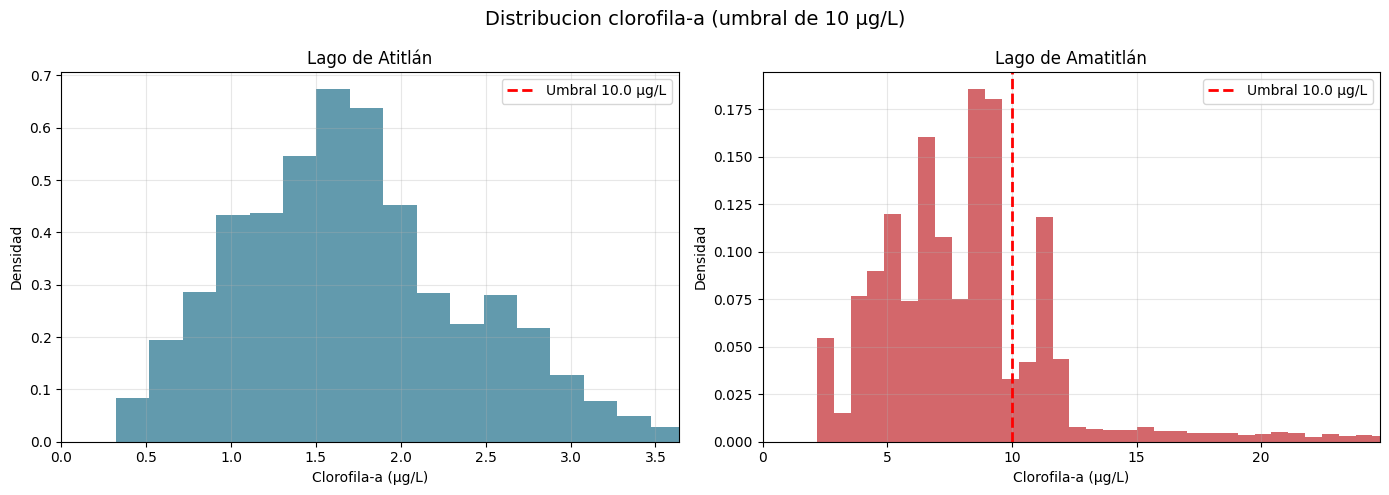

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = df_ml[df_ml['lago'] == lago]
    color = '#1f6f8b' if lago == 'Atitlan' else '#c1272d'

    # Histograma
    axes[i].hist(sub['chl'], bins=50, alpha=0.7, color=color, density=True)
    axes[i].axvline(UMBRAL_CHL, color='red', linestyle='--',
                    linewidth=2, label=f'Umbral {UMBRAL_CHL} µg/L')
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]}')
    axes[i].set_xlabel('Clorofila-a (µg/L)')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    # Limitar eje x para mejor visualización
    axes[i].set_xlim(0, min(50, sub['chl'].quantile(0.99)))

plt.suptitle('Distribucion clorofila-a (umbral de 10 µg/L)', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Distribución variable

ANALISIS DISTRIBUCION VARIABLE RESPUESTA

----------------------------------------
DISTRIBUCION GLOBAL
----------------------------------------
Total observaciones: 29,462
Clase 0 (ausencia/baja): 26,356 (89.46%)
Clase 1 (alta presencia): 3,106 (10.54%)


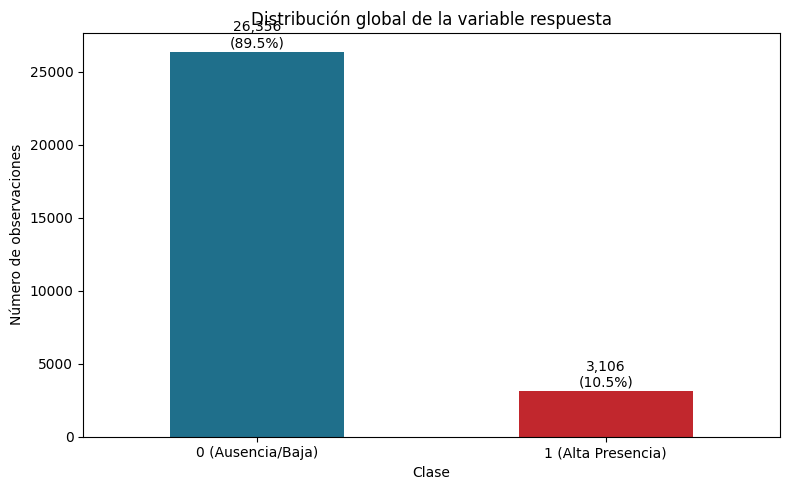


----------------------------------------
DISTRIBUCION POR LAGO
----------------------------------------

Lago de Atitlán:
  Total: 15,000 observaciones
  Clase 0: 14,999 (100.0%)
  Clase 1: 1 (0.0%)

Lago de Amatitlán:
  Total: 14,462 observaciones
  Clase 0: 11,357 (78.5%)
  Clase 1: 3,105 (21.5%)


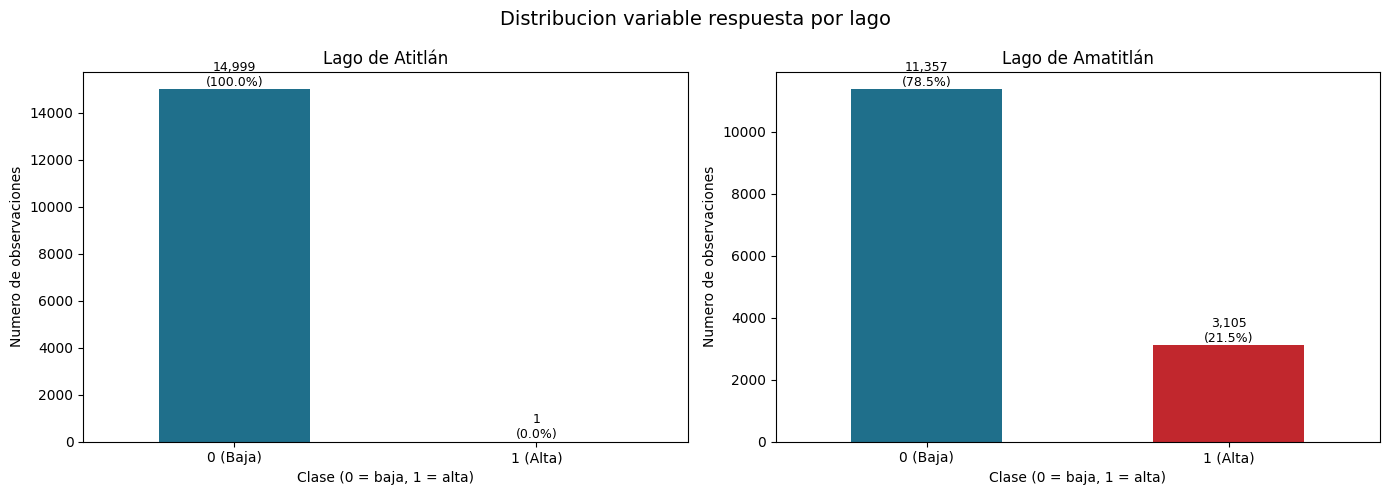


----------------------------------------
DISTRIBUCION POR FECHA
----------------------------------------

Proporcion de clase 1 por fecha:
lago        Amatitlan  Atitlan
fecha                         
2025-01-31        4.1      0.0
2025-02-28        0.0      0.0
2025-03-31        9.8      0.0
2025-04-30       16.5      0.0
2025-05-31       15.7      0.0
2025-06-30      100.0      0.0
2025-07-31      100.0      0.1
2025-08-31        7.4      0.0
2025-09-30        7.7      0.0
2025-10-31       10.1      0.0
2025-11-30        5.3      0.0
2025-12-31        5.9      0.0
2026-01-31        6.2      0.0
2026-02-28       13.1      0.0
2026-03-31       12.4      0.0


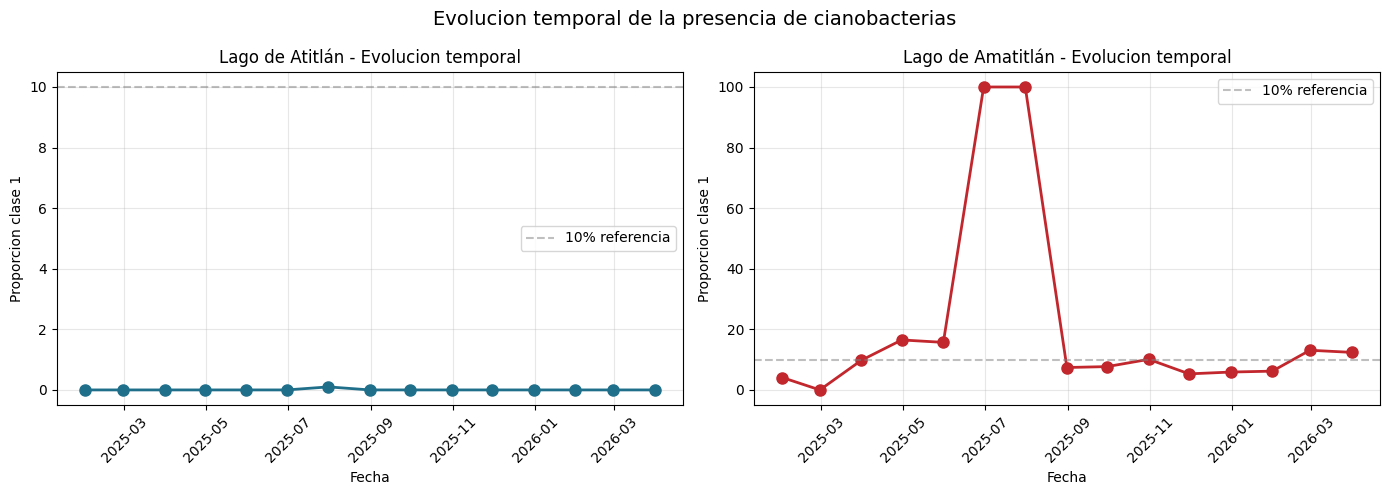


----------------------------------------
ANALISIS ESTADISTICO
----------------------------------------

Lago de Atitlán:
  Media de chl: 1.74 µg/L
  Mediana de chl: 1.67 µg/L
  P95 de chl: 2.98 µg/L
  Proporcion clase 1: 0.0%
  Chl media - clase 0: 1.74 µg/L
  Chl media - clase 1: 10.16 µg/L

Lago de Amatitlán:
  Media de chl: 8.30 µg/L
  Mediana de chl: 7.97 µg/L
  P95 de chl: 15.42 µg/L
  Proporcion clase 1: 21.5%
  Chl media - clase 0: 6.77 µg/L
  Chl media - clase 1: 13.86 µg/L


In [ ]:
print("="*60)
print("ANALISIS DISTRIBUCION VARIABLE RESPUESTA")
print("="*60)

print("\n" + "-"*40)
print("DISTRIBUCION GLOBAL")
print("-"*40)

total = len(df_ml)
clase0 = len(df_ml[df_ml['ciano_presente']==0])
clase1 = len(df_ml[df_ml['ciano_presente']==1])

print(f"Total observaciones: {total:,}")
print(f"Clase 0 (ausencia/baja): {clase0:,} ({100*clase0/total:.2f}%)")
print(f"Clase 1 (alta presencia): {clase1:,} ({100*clase1/total:.2f}%)")

#barras
fig, ax = plt.subplots(figsize=(8, 5))
df_ml['ciano_presente'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#1f6f8b', '#c1272d']
)
ax.set_xlabel('Clase')
ax.set_ylabel('Número de observaciones')
ax.set_title('Distribución global de la variable respuesta')
ax.set_xticklabels(['0 (Ausencia/Baja)', '1 (Alta Presencia)'], rotation=0)

for i, v in enumerate(df_ml['ciano_presente'].value_counts().sort_index()):
    ax.text(i, v + 100, f'{v:,}\n({100*v/len(df_ml):.1f}%)',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "-"*40)
print("DISTRIBUCION POR LAGO")
print("-"*40)

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Total: {len(sub):,} observaciones")
    print(f"  Clase 0: {len(sub[sub['ciano_presente']==0]):,} ({100*(1-sub['ciano_presente'].mean()):.1f}%)")
    print(f"  Clase 1: {len(sub[sub['ciano_presente']==1]):,} ({100*sub['ciano_presente'].mean():.1f}%)")

#graficas/lago
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = df_ml[df_ml['lago'] == lago]
    sub['ciano_presente'].value_counts().sort_index().plot(
        kind='bar', ax=axes[i], color=['#1f6f8b', '#c1272d']
    )
    axes[i].set_xlabel('Clase (0 = baja, 1 = alta)')
    axes[i].set_ylabel('Numero de observaciones')
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]}')
    axes[i].set_xticklabels(['0 (Baja)', '1 (Alta)'], rotation=0)

    for j, v in enumerate(sub['ciano_presente'].value_counts().sort_index()):
        axes[i].text(j, v + 20, f'{v:,}\n({100*v/len(sub):.1f}%)',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribucion variable respuesta por lago', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "-"*40)
print("DISTRIBUCION POR FECHA")
print("-"*40)

#tabla propor
tabla_fechas = df_ml.groupby(['lago', 'fecha']).agg({
    'ciano_presente': ['count', 'mean']
}).round(4)
tabla_fechas.columns = ['total', 'proporcion_clase1']
tabla_fechas['proporcion_clase1'] = (100 * tabla_fechas['proporcion_clase1']).round(1)
tabla_fechas = tabla_fechas.reset_index()

print("\nProporcion de clase 1 por fecha:")
print(tabla_fechas.pivot(index='fecha', columns='lago', values='proporcion_clase1').round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    sub = tabla_fechas[tabla_fechas['lago'] == lago]
    color = config.COLOR[lago]

    axes[i].plot(sub['fecha'], sub['proporcion_clase1'], 'o-',
                 color=color, linewidth=2, markersize=8)
    axes[i].axhline(10, color='gray', linestyle='--', alpha=0.5, label='10% referencia')
    axes[i].set_xlabel('Fecha')
    axes[i].set_ylabel('Proporcion clase 1')
    axes[i].set_title(f'{config.NOMBRE_LARGO[lago]} - Evolucion temporal')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Evolucion temporal de la presencia de cianobacterias', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "-"*40)
print("ANALISIS ESTADISTICO")
print("-"*40)

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Media de chl: {sub['chl'].mean():.2f} µg/L")
    print(f"  Mediana de chl: {sub['chl'].median():.2f} µg/L")
    print(f"  P95 de chl: {sub['chl'].quantile(0.95):.2f} µg/L")
    print(f"  Proporcion clase 1: {100*sub['ciano_presente'].mean():.1f}%")

    print(f"  Chl media - clase 0: {sub[sub['ciano_presente']==0]['chl'].mean():.2f} µg/L")
    print(f"  Chl media - clase 1: {sub[sub['ciano_presente']==1]['chl'].mean():.2f} µg/L")

### 2.4 Balance

ANALISIS DESBALANCE ENTRE CLASES

----------------------------------------
MEDICION DESBALANCE
----------------------------------------

GLOBAL:
  Clase 0: 26,356 (89.46%)
  Clase 1: 3,106 (10.54%)
  Ratio desbalance (0/1): 8.49:1

Lago de Atitlán:
  Clase 0: 14,999 (99.99%)
  Clase 1: 1 (0.01%)
  Ratio desbalance (0/1): 14999.00:1
  Grado: EXTREMO - Clase minoritaria muy escasa

Lago de Amatitlán:
  Clase 0: 11,357 (78.53%)
  Clase 1: 3,105 (21.47%)
  Ratio desbalance (0/1): 3.66:1
  Grado: MODERADO - Desbalance moderado


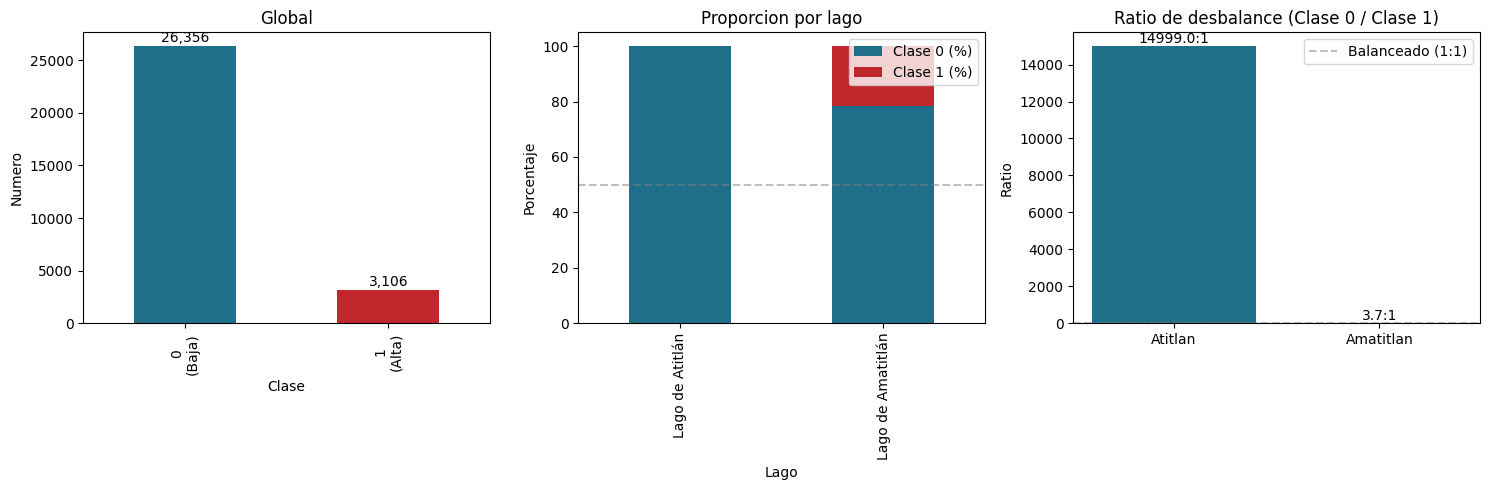


----------------------------------------
INDICES DESBALANCE
----------------------------------------

Lago de Atitlán:
  Peso clase 0: 0.500
  Peso clase 1: 7500.000
  Factor de compensacion: 14999.00x

Lago de Amatitlán:
  Peso clase 0: 0.637
  Peso clase 1: 2.329
  Factor de compensacion: 3.66x


In [ ]:
print("="*60)
print("ANALISIS DESBALANCE ENTRE CLASES")
print("="*60)

print("\n" + "-"*40)
print("MEDICION DESBALANCE")
print("-"*40)

total = len(df_ml)
clase0 = len(df_ml[df_ml['ciano_presente']==0])
clase1 = len(df_ml[df_ml['ciano_presente']==1])
ratio = clase0 / clase1

print(f"\nGLOBAL:")
print(f"  Clase 0: {clase0:,} ({100*clase0/total:.2f}%)")
print(f"  Clase 1: {clase1:,} ({100*clase1/total:.2f}%)")
print(f"  Ratio desbalance (0/1): {ratio:.2f}:1")

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    total_lago = len(sub)
    c0 = len(sub[sub['ciano_presente']==0])
    c1 = len(sub[sub['ciano_presente']==1])
    ratio_lago = c0 / c1 if c1 > 0 else float('inf')

    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    print(f"  Clase 0: {c0:,} ({100*c0/total_lago:.2f}%)")
    print(f"  Clase 1: {c1:,} ({100*c1/total_lago:.2f}%)")
    print(f"  Ratio desbalance (0/1): {ratio_lago:.2f}:1")

    if ratio_lago > 10:
        print(f"  Grado: EXTREMO - Clase minoritaria muy escasa")
    elif ratio_lago > 5:
        print(f"  Grado: ALTO - Desbalance significativo")
    elif ratio_lago > 2:
        print(f"  Grado: MODERADO - Desbalance moderado")
    elif ratio_lago < 0.5:
        print(f"  Grado: INVERTIDO - Clase 1 es mayoritaria")
    else:
        print(f"  Grado: BAJO - Clases relativamente balanceadas")

#desb.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
df_ml['ciano_presente'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#1f6f8b', '#c1272d']
)
ax.set_title('Global', fontsize=12)
ax.set_xlabel('Clase')
ax.set_ylabel('Numero')
ax.set_xticklabels(['0\n(Baja)', '1\n(Alta)'])
for i, v in enumerate(df_ml['ciano_presente'].value_counts().sort_index()):
    ax.text(i, v + 100, f'{v:,}', ha='center', va='bottom')

#Porp. lagos
ax = axes[1]
lago_data = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    lago_data.append({
        'Lago': config.NOMBRE_LARGO[lago],
        'Clase 0 (%)': 100*(1-sub['ciano_presente'].mean()),
        'Clase 1 (%)': 100*sub['ciano_presente'].mean()
    })
lago_df = pd.DataFrame(lago_data)
lago_df.plot(x='Lago', kind='bar', ax=ax, stacked=True,
             color=['#1f6f8b', '#c1272d'])
ax.set_title('Proporcion por lago', fontsize=12)
ax.set_ylabel('Porcentaje')
ax.legend(loc='upper right')
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)

#desbalace raito
ax = axes[2]
ratios = []
for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    c0 = len(sub[sub['ciano_presente']==0])
    c1 = len(sub[sub['ciano_presente']==1])
    ratios.append(c0/c1 if c1 > 0 else 0)

bars = ax.bar(['Atitlan', 'Amatitlan'], ratios, color=['#1f6f8b', '#c1272d'])
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Balanceado (1:1)')
ax.set_title('Ratio de desbalance (Clase 0 / Clase 1)', fontsize=12)
ax.set_ylabel('Ratio')
ax.legend()

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{ratio:.1f}:1', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "-"*40)
print("INDICES DESBALANCE")
print("-"*40)

from sklearn.utils import class_weight

for lago in ["Atitlan", "Amatitlan"]:
    sub = df_ml[df_ml['lago'] == lago]
    y = sub['ciano_presente'].values

    weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y),
        y=y
    )

    print(f"\n{config.NOMBRE_LARGO[lago]}:")
    for i, cls in enumerate(np.unique(y)):
        print(f"  Peso clase {cls}: {weights[i]:.3f}")
    print(f"  Factor de compensacion: {weights[1]/weights[0]:.2f}x")

Hay un desbalance significativo, sobretodo en el lago atitlán siendo este bastante extremo. Debido a este descomunal desbalance el modelo no es capaz de aprender, se daría un sobreajuste y la división de datos sería inservible.

Por otro lado en el caso de Amatitlan, el balance es moderado siendo un 21.47% de pixeles que superaron el umbral, sin embargo cuenta con un sesgo a la clase 0. Esto podría afectar metricas como el recall.

### 2.5 Descarte variables

In [ ]:
print("="*60)
print("VARIABLES QUE NO PUEDEN USARSE COMO PREDICTORAS")
print("="*60)
print("\n" + "-"*40)
print("VARIABLES PROHIBIDAS EN DATASET")
print("-"*40)

variables_prohibidas = ['chl', 'ndci', 'ciano_presente']
variables_permitidas = [col for col in df_ml.columns if col not in variables_prohibidas]

print(f"\nVariables en el dataset: {df_ml.columns.tolist()}")
print(f"\nProhibidas (leakage): {variables_prohibidas}")
print(f"Permitidas como predictoras: {variables_permitidas}")

print("\n" + "-"*40)
print("VARIABLES RECOMENDADAS PARA MODELADO")
print("-"*40)

predictoras_recomendadas = [
    'B02', 'B03', 'B04', 'B05', 'B08',  #bandsa
    'ndvi', 'ndwi', 'fai',
    'lago'
]

print("\nPredictoras espectrales (5):")
print(f"  {', '.join(['B02', 'B03', 'B04', 'B05', 'B08'])}")

print("\nIndices (3):")
print(f"  {', '.join(['NDVI', 'NDWI', 'FAI'])}")

print("\nVariable categorica:")
print(f"  Lago (Atitlan/Amatitlan)")

print(f"\nTotal: {len(predictoras_recomendadas)} variables predictoras")
print(f"Variable objetivo: 'ciano_presente' (binaria)")

print("\n" + "-"*40)
print("VERIFICACION VARIABLES DISPONIBLES")
print("-"*40)

disponibles = [col for col in predictoras_recomendadas if col in df_ml.columns]
faltantes = [col for col in predictoras_recomendadas if col not in df_ml.columns]

print(f"Disponibles: {disponibles}")
if faltantes:
    print(f"Faltantes en dataset: {faltantes}")


print("\n" + "-"*40)
print("RESUMEN")
print("-"*40)

resumen_variables = pd.DataFrame({
    'Variable': ['chl', 'ndci', 'ciano_presente'] + predictoras_recomendadas,
    'Tipo': ['Objetivo'] + ['Objetivo'] + ['Objetivo'] + ['Predictora']*len(predictoras_recomendadas),
    'Permitida como predictora': ['NO']*3 + ['SÍ']*len(predictoras_recomendadas)
})

print(resumen_variables.to_string(index=False))



VARIABLES QUE NO PUEDEN USARSE COMO PREDICTORAS

----------------------------------------
VARIABLES PROHIBIDAS EN DATASET
----------------------------------------

Variables en el dataset: ['lago', 'fecha', 'chl', 'ndvi', 'ndwi', 'ndci', 'fai', 'B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'x', 'y', 'ciano_presente']

Prohibidas (leakage): ['chl', 'ndci', 'ciano_presente']
Permitidas como predictoras: ['lago', 'fecha', 'ndvi', 'ndwi', 'fai', 'B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'x', 'y']

----------------------------------------
VARIABLES RECOMENDADAS PARA MODELADO
----------------------------------------

Predictoras espectrales (5):
  B02, B03, B04, B05, B08

Indices (3):
  NDVI, NDWI, FAI

Variable categorica:
  Lago (Atitlan/Amatitlan)

Total: 9 variables predictoras
Variable objetivo: 'ciano_presente' (binaria)

----------------------------------------
VERIFICACION VARIABLES DISPONIBLES
--------------------------------------

In [ ]:
variables_predictoras = ['B02', 'B03', 'B04', 'B05', 'B08', 'ndvi', 'ndwi', 'fai', 'lago']
variables_prohibidas = ['chl', 'ndci', 'ciano_presente']

overlap = set(variables_predictoras) & set(variables_prohibidas)
print(f"Variables overlap: {overlap}")

Variables overlap: set()


Automaticamente se excluyen las variables leakeage por varias razones:
Chl es la varaible respuesta original (daría accuracy falso), ndci por que el polinomio de clorofila usa ndci y ciano_presente por el hecho de que esta es la que se quiere predecir.


Las variables que podriamos usar son las proporcionadas por las bandas al ser datos del sensor, los indices NDVI, NDWI, FAI por no tener relacion con chl de forma directa y pudiendo calcularse en abse a las bandas. Y, obviamente, se usaría la variable lago para identificar los resultados correspondientes.

## Selección y construcción de variables predictoras

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

### 3.1 Definicion conjunto variables predictoras

In [ ]:
print("="*60)
print("VARIABLES SELECCIONADAS")
print("="*60)

VAR_PRED = [
    #bandas
    'B02', 'B03', 'B04', 'B05', 'B08',
    #indices
    'ndvi', 'ndwi', 'fai',
    'lago'
]

VAR_OBJ = 'ciano_presente'

print(f"\nVariables predictoras seleccionadas ({len(VAR_PRED)}):")
for i, var in enumerate(VAR_PRED, 1):
    print(f"  {i}. {var}")
print(f"\nVariable objetivo: {VAR_OBJ}")

SELECCION VARIABLES PREDICTORAS

Variables predictoras seleccionadas (9):
  1. B02
  2. B03
  3. B04
  4. B05
  5. B08
  6. ndvi
  7. ndwi
  8. fai
  9. lago

Variable objetivo: ciano_presente


### 3.2 Explicacion variables
- B02: Banda espectral con longitud de 490nm (azul), detecta agua limpia ya que la presencia de la clorofila afecta la reflectancia del azul del agua.
- B03: Banda espectral con longitud 560nm (verde), detecta la clorofila en el agua, indicando la presencia de la bacteria en cuestión. Es clave apara NDWI.
- B04: Banda espectral con longitud 665 nm (Rojo), la clorofila absorbe fuertemente en rojo por lo que un bajo índice significa que hay algas.
- B05: Banda espectral con longitud 705nm (Borde rojo), la clorofila refleja fuertemente en esta banda y el contraste B04/B05 es vital para NDCI, es específica para la bacteria.
- B08: Banda espectral con longitud 842 nm (Infrarrojo cercano - NIR), el agua con algas y vegetacion reflejan NIR ayudando a formar los índices de vegetación y agua, cosa importante para NDCI y NDWI.
- NDVI: Indice de vegetacion por medio de bandas B04 y B08, un NDVI negativo idica agua limpia y el psitivo indica precencia de vegetación y algas.
- NDWI: Indice de agua por medio de bandas B03 y B08, el NDWI positivo indica la presencia de agua, mientras que si es negativo indica vegetecion y otros elementos como el suelo. Este valor disminuye dependiendo de la presencia de algas.
- FAI: Indice de algas flotantes, indica acumulaciones de algas en la superficie, de los cuales un valor alto indica que estas tienen floraciones densas.
- Lago: Identifica si es el lago atitlan o amatitlan

## 3.3 Ingeniería de características

In [39]:
print("\n" + "="*60)
print("INGENIERIA CARACTERISTICAS")
print("="*60)

df_ml_engineered = df_ml.copy()

#rel B04/B05 (prop. rojo/borde rojo)
df_ml_engineered['ratio_B04_B05'] = df_ml_engineered['B04'] / (df_ml_engineered['B05'] + 0.0001)

#dif B05 - B04 (señal directa clorofila)
df_ml_engineered['diff_B05_B04'] = df_ml_engineered['B05'] - df_ml_engineered['B04']

#prod NDVI * NDWI
df_ml_engineered['ndvi_ndwi_product'] = df_ml_engineered['ndvi'] * df_ml_engineered['ndwi']

#indice (NDCI + FAI + NDWI)
df_ml_engineered['combined_index'] = df_ml_engineered['ndci'] + df_ml_engineered['fai'] + df_ml_engineered['ndwi']

#prop verde/NIR
df_ml_engineered['ratio_B03_B08'] = df_ml_engineered['B03'] / (df_ml_engineered['B08'] + 0.0001)

#brillantez total (indicador de turbidez)
df_ml_engineered['brightness'] = df_ml_engineered['B02'] + df_ml_engineered['B03'] + df_ml_engineered['B04']

print("\nVARIABLES ADICIONALES CREADAS:")
nuevas_vars = [
    ('ratio_B04_B05', 'Proporción rojo/borde rojo', 'Mide contraste clave para clorofila'),
    ('diff_B05_B04', 'Diferencia borde rojo - rojo', 'Señal directa clorofila'),
    ('ndvi_ndwi_product', 'Producto NDVI × NDWI', 'Detecta agua con actividad vegetal'),
    ('combined_index', 'Índice combinado', 'Agrega señal NDCI, FAI y NDWI'),
    ('ratio_B03_B08', 'Proporción verde/NIR', 'Complementa NDWI'),
    ('brightness', 'Brillantez total', 'Indicador turbidez')
]

for nombre, desc, just in nuevas_vars:
    print(f"  - {nombre}: {desc}")


INGENIERIA CARACTERISTICAS

VARIABLES ADICIONALES CREADAS:
  - ratio_B04_B05: Proporción rojo/borde rojo
  - diff_B05_B04: Diferencia borde rojo - rojo
  - ndvi_ndwi_product: Producto NDVI × NDWI
  - combined_index: Índice combinado
  - ratio_B03_B08: Proporción verde/NIR
  - brightness: Brillantez total


## 4. Construcción de modelos de Machine Learning

In [42]:
print("\n" + "="*60)
print("PREPARACION DATOS PARA MODELADO")
print("="*60)

#ecluir atiltan por desbalance
df_modelo = df_ml_engineered[df_ml_engineered['lago'] == 'Amatitlan'].copy()
print(f"Dataset final: {len(df_modelo):,} observaciones")

VAR_MODEL = [
    'B02', 'B03', 'B04', 'B05', 'B08',
    'ndvi', 'ndwi', 'fai',
    'ratio_B04_B05', 'diff_B05_B04', 'ndvi_ndwi_product',
    'combined_index', 'ratio_B03_B08', 'brightness'
]

print(f"\nVariables predictoras finales: {len(VAR_MODEL)}\n")

#X y y
X = df_modelo[VAR_MODEL].copy()
y = df_modelo['ciano_presente'].copy()

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribucion y:\n{y.value_counts()}")


print("\n" + "="*60)
print("ENTRENAMIENTO (70/30)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {len(X_train):,} observaciones")
print(f"  Clase 0: {sum(y_train==0):,}")
print(f"  Clase 1: {sum(y_train==1):,}")

print(f"\nPrueba: {len(X_test):,} observaciones")
print(f"  Clase 0: {sum(y_test==0):,}")
print(f"  Clase 1: {sum(y_test==1):,}")

#escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



PREPARACION DATOS PARA MODELADO
Dataset final: 14,462 observaciones

Variables predictoras finales: 14

Shape X: (14462, 14)
Shape y: (14462,)

Distribucion y:
ciano_presente
0    11357
1     3105
Name: count, dtype: int64

ENTRENAMIENTO (70/30)

Entrenamiento: 10,123 observaciones
  Clase 0: 7,950
  Clase 1: 2,173

Prueba: 4,339 observaciones
  Clase 0: 3,407
  Clase 1: 932


In [45]:
print("\n" + "="*60)
print("CONSTRUCCION MODELOS")
print("="*60)

#pesos
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nPesos clase:\n{weights_dict}")

#regresion log
print("\n" + "-"*40)
print("REGRESION LOGISTICA")
print("-"*40)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

#random forest
print("\n" + "-"*40)
print("RANDOM FOREST")
print("-"*40)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print("\nImportancia caracteristicas:")
print(importancias.to_string(index=False))


CONSTRUCCION MODELOS

Pesos clase:
{0: np.float64(0.6366666666666667), 1: np.float64(2.3292682926829267)}

----------------------------------------
REGRESION LOGISTICA
----------------------------------------
F1-Score: 0.7119
AUC-ROC: 0.9354

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      3407
           1       0.62      0.84      0.71       932

    accuracy                           0.85      4339
   macro avg       0.78      0.85      0.81      4339
weighted avg       0.88      0.85      0.86      4339


----------------------------------------
RANDOM FOREST
----------------------------------------
F1-Score: 0.6130
AUC-ROC: 0.8605

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3407
           1       0.61      0.62      0.61       932

    accuracy                           0.83      4339
   macro avg       0.75      0.76 

##